# Phân tích khám phá dữ liệu kết quả học tập sinh viên

Bộ dữ liệu gồm **200,000 bản ghi sinh viên** và **15 thuộc tính**, phản ánh đồng thời nền tảng gia đình, hành vi học tập, điều kiện sinh hoạt, trạng thái tâm lý và kết quả học thuật. Trọng tâm phân tích không chỉ nằm ở việc mô tả dữ liệu, mà còn ở việc nhận diện các tín hiệu có khả năng hỗ trợ mô hình dự đoán `pass_fail`.

Bốn câu hỏi nghiên cứu định hướng toàn bộ phần EDA:

1. Chất lượng dữ liệu có đủ ổn định để làm nền cho mô hình Machine Learning hay không?
2. Hồ sơ sinh viên trong mẫu có đặc điểm trung tâm và mức phân hóa như thế nào?
3. Các nhóm biến hành vi, tâm lý và nền tảng gia đình liên hệ ra sao với kết quả học tập?
4. Những biến nào thể hiện tín hiệu rõ nhất với biến mục tiêu `pass_fail`?

In [2]:
import sys
!"{sys.executable}" -m pip install pandas matplotlib seaborn

## 1. Nguồn dữ liệu và phạm vi quan sát

Dữ liệu được lưu trữ trên Hadoop HDFS và truy xuất thông qua WebHDFS, phù hợp với bối cảnh dữ liệu có quy mô lớn và không đưa trực tiếp vào repository. Sau khi tải về môi trường phân tích, tập dữ liệu được xem như một lát cắt hồ sơ học tập của sinh viên.

Các biến quan sát bao phủ năm nhóm thông tin chính: nhân khẩu học (`gender`, `age`), nền tảng gia đình (`parental_education_level`, `family_income`), hành vi học tập (`daily_study_hours`, `attendance_rate`, `private_tutoring`), điều kiện sinh hoạt và tâm lý (`sleep_hours`, `stress_level`, `motivation_score`, `internet_quality`), cùng nhóm kết quả học thuật (`math_score`, `reading_score`, `writing_score`, `pass_fail`).

In [3]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen

# Thêm đường dẫn src để import file cấu hình settings.py
sys.path.append('../src')
from config.settings import HDFS_URL

# Trích xuất IP tĩnh của máy chủ từ HDFS_URL (Tailscale IP)
host_ip = HDFS_URL.split('://')[1].split(':')[0]
url = f"http://{host_ip}:9870/webhdfs/v1/student_data.csv?op=OPEN"

try:
    with urlopen(url) as response:
        df = pd.read_csv(response)
    print("Tải thành công dữ liệu từ HDFS (qua Tailscale)")
    print(f"Tổng số dòng dữ liệu: {len(df)}")
    
    # Hiển thị 5 dòng đầu để kiểm tra
    display(df.head())
except Exception as e:
    print(" Lỗi kết nối đến HDFS:", e)


Tải thành công dữ liệu từ HDFS (qua Tailscale)
Tổng số dòng dữ liệu: 200000


,gender,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,private_tutoring,internet_quality,math_score,reading_score,writing_score,pass_fail
0,Female,15,2,45000.0,2.9,0.916,8.3,6.0,16,False,2,21,29,29,Fail
1,Male,19,2,15000.0,2.8,0.760,6.8,5.0,58,False,3,56,37,45,Fail
2,Female,20,5,55000.0,4.0,0.894,8.2,6.0,51,False,3,60,51,63,Fail
3,Female,16,5,65000.0,4.6,0.888,6.2,6.0,49,False,3,58,54,34,Fail
4,Male,20,4,35000.0,4.3,0.923,7.3,4.0,62,False,2,80,57,73,Pass


## 1.2. Quy mô và cấu trúc dữ liệu

Quy mô, kiểu dữ liệu và tỷ lệ khuyết thiếu quyết định mức độ tin cậy của các phân tích tiếp theo. Với bài toán dự đoán `pass_fail`, phần cấu trúc dữ liệu còn cho biết biến nào là feature đầu vào, biến nào là nhãn mục tiêu, và biến nào có nguy cơ tạo rò rỉ thông tin nếu xử lý không đúng.

In [4]:
print("=== THÔNG TIN CHUNG VỀ BỘ DỮ LIỆU ===")
df.info()

=== THÔNG TIN CHUNG VỀ BỘ DỮ LIỆU ===
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   gender                    200000 non-null  str    
 1   age                       200000 non-null  int64  
 2   parental_education_level  200000 non-null  int64  
 3   family_income             195975 non-null  float64
 4   daily_study_hours         200000 non-null  float64
 5   attendance_rate           200000 non-null  float64
 6   sleep_hours               195887 non-null  float64
 7   stress_level              196087 non-null  float64
 8   motivation_score          200000 non-null  int64  
 9   private_tutoring          200000 non-null  bool   
 10  internet_quality          200000 non-null  int64  
 11  math_score                200000 non-null  int64  
 12  reading_score             200000 non-null  int64  
 13  writing_score    

In [5]:
print("\n=== KÍCH THƯỚC BỘ DỮ LIỆU ===")
print(f"Số lượng sinh viên (Dòng): {df.shape[0]}")
print(f"Số lượng thuộc tính (Cột): {df.shape[1]}")


=== KÍCH THƯỚC BỘ DỮ LIỆU ===
Số lượng sinh viên (Dòng): 200000
Số lượng thuộc tính (Cột): 15


### Nhận xét về cấu trúc dữ liệu

Bộ dữ liệu có **200,000 quan sát** và **15 biến**, tạo nền mẫu đủ lớn cho thống kê mô tả và các thử nghiệm mô hình hóa. Cấu trúc biến tương đối rõ: **12 biến số/định lượng**, **2 biến chuỗi** (`gender`, `pass_fail`) và **1 biến Boolean** (`private_tutoring`).

Giá trị khuyết chỉ tập trung ở ba biến: `family_income` (**4,025 dòng, khoảng 2.01%**), `sleep_hours` (**4,113 dòng, khoảng 2.06%**) và `stress_level` (**3,913 dòng, khoảng 1.96%**). Mức khuyết thiếu thấp, phân tán trong các biến có ý nghĩa phân tích, cho thấy việc bổ khuyết có kiểm soát hợp lý hơn so với loại bỏ dòng. Quy mô mẫu vì vậy vẫn được bảo toàn cho các phân tích sau.

# 2. Kiểm định chất lượng dữ liệu và tiền xử lý

Chất lượng dữ liệu được đánh giá qua ba khía cạnh: trùng lặp, ngoại lai và khuyết thiếu. Các xử lý ở phần này hướng đến hai mục tiêu phân tích: giữ lại tối đa thông tin thật của mẫu nghiên cứu và tránh tạo ra tín hiệu giả cho mô hình dự đoán.

## 2.1. Kiểm tra trùng lặp

Dòng trùng lặp có thể làm phóng đại một nhóm sinh viên và làm lệch các thống kê trung tâm. Kết quả kiểm tra cho biết mức độ độc lập của các quan sát trước khi đi vào mô tả phân phối và mô hình hóa.

In [6]:
Duplicate_value = df.duplicated().sum()
print(f"Phat hien {Duplicate_value} dong trung lap.")

Phat hien 0 dong trung lap.


Không phát hiện dòng trùng lặp trong bộ dữ liệu. Điều này củng cố độ tin cậy ban đầu của mẫu: toàn bộ **200,000 quan sát** có thể được giữ lại mà không làm tăng giả tạo tần suất của một nhóm sinh viên nào.

## 2.2. Miền giá trị và giá trị ngoại lai

Ngoại lai trong bộ dữ liệu giáo dục không mặc nhiên là lỗi. Một phần ngoại lai có thể phản ánh các sinh viên có thành tích rất thấp, mức chuyên cần bất thường, thu nhập gia đình rất cao hoặc hành vi học tập khác biệt. Vì vậy, phân tích ngoại lai tập trung vào việc phân biệt sai lệch logic với cực trị có ý nghĩa thực tế.

Các miền giá trị quan trọng gồm thang điểm 0-100, `attendance_rate` trong khoảng 0-1, và các biến thời lượng không âm trong phạm vi sinh hoạt hợp lý.

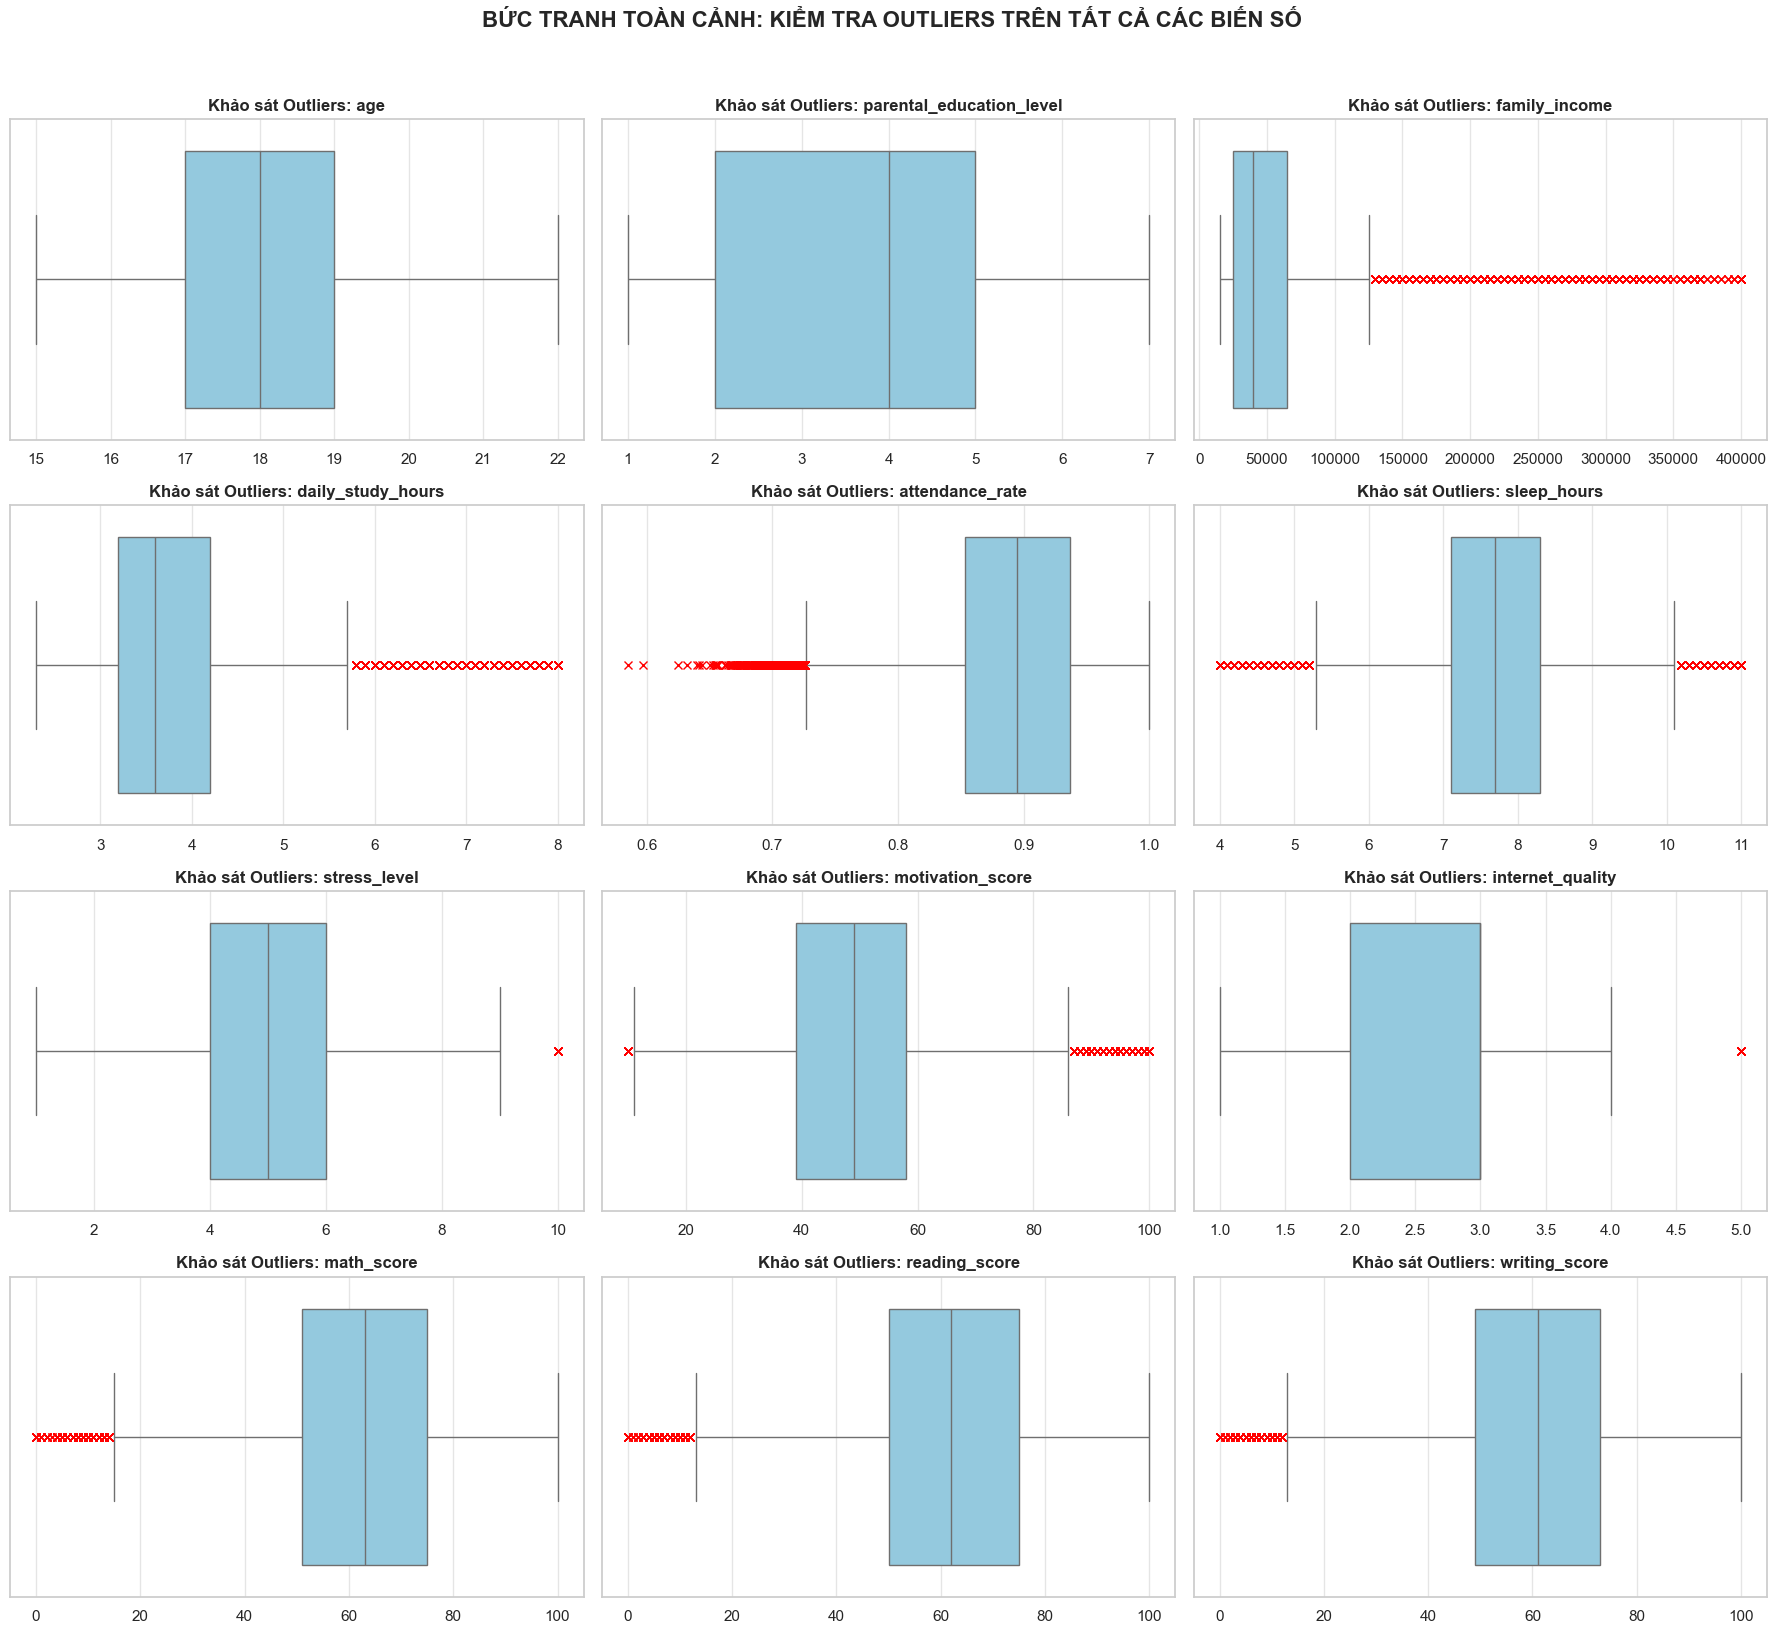

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tự động lấy danh sách tất cả các cột có kiểu dữ liệu là số
cac_cot_so = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = len(cac_cot_so)

# 2. Tính toán số lượng hàng cần vẽ (Mỗi hàng ta xếp 3 biểu đồ cho gọn và đẹp)
cols_per_row = 3
num_rows = (num_cols + cols_per_row - 1) // cols_per_row

# 3. Khởi tạo khung tranh tổng thể
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(18, 4 * num_rows))
fig.suptitle('BỨC TRANH TOÀN CẢNH: KIỂM TRA OUTLIERS TRÊN TẤT CẢ CÁC BIẾN SỐ', fontsize=16, fontweight='bold', y=1.02)

# Phẳng hóa mảng axes để dùng vòng lặp cho dễ
axes = axes.flatten()

# 4. Vòng lặp tự động vẽ Boxplot cho từng cột số
for i, col in enumerate(cac_cot_so):
    sns.boxplot(ax=axes[i], x=df[col], color='skyblue', flierprops={"marker": "x", "markeredgecolor": "red"})
    axes[i].set_title(f'Khảo sát Outliers: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

# 5. Ẩn đi các ô biểu đồ thừa nếu số lượng cột không chia hết cho 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.3. Diễn giải ngoại lai và quyết định xử lý

Boxplot và thống kê mô tả cho thấy các biến chính không vượt miền logic: điểm số nằm trong khoảng **0-100**, `attendance_rate` nằm trong khoảng **0.58-1.00**, `daily_study_hours` nằm trong khoảng **2.30-8.00** và `sleep_hours` nằm trong khoảng **4.00-11.00**. Các điểm nằm ngoài khoảng phân bố chính vì vậy được xem là cực trị hợp lệ, không phải lỗi nhập liệu.

- Nhóm điểm số (`math_score`, `reading_score`, `writing_score`) xuất hiện các mức rất thấp, bao gồm 0 điểm. Đây là nhóm quan sát có ý nghĩa lớn với bài toán `Fail`, vì chúng đại diện cho vùng rủi ro học tập cao.
- `family_income` lệch phải rõ rệt: trung bình khoảng **51,328** nhưng trung vị chỉ **40,000**, trong khi giá trị lớn nhất đạt **400,000**. Khoảng cách này cho thấy một nhóm nhỏ thu nhập rất cao đang kéo trung bình lên, nên trung vị phản ánh mức thu nhập điển hình tốt hơn.
- Các biến hành vi như `daily_study_hours`, `attendance_rate`, `sleep_hours`, `stress_level` và `motivation_score` có cực trị nhưng vẫn phù hợp với thực tế giáo dục, đặc biệt trong một mẫu lớn 200,000 quan sát.

Từ các quan sát trên, ngoại lai được giữ lại trong EDA. Quyết định này bảo toàn các trường hợp có rủi ro hoặc khác biệt hành vi, vốn có thể chứa tín hiệu quan trọng cho mô hình dự đoán.

    ## 2.4. Dữ liệu khuyết thiếu

Khuyết thiếu tập trung ở `family_income`, `sleep_hours` và `stress_level`, mỗi biến xấp xỉ 2%. Trong bối cảnh dự đoán `pass_fail`, điểm đáng chú ý không chỉ là tỷ lệ khuyết thiếu thấp, mà còn là cách bổ khuyết phải không sử dụng thông tin từ biến mục tiêu.

In [8]:
print("\n=== KIỂM TRA DỮ LIỆU BỊ KHUYẾT THIẾU ===")
print(df.isnull().sum())


=== KIỂM TRA DỮ LIỆU BỊ KHUYẾT THIẾU ===
gender                         0
age                            0
parental_education_level       0
family_income               4025
daily_study_hours              0
attendance_rate                0
sleep_hours                 4113
stress_level                3913
motivation_score               0
private_tutoring               0
internet_quality               0
math_score                     0
reading_score                  0
writing_score                  0
pass_fail                      0
dtype: int64


### 2.5. Lựa chọn bổ khuyết theo bản chất biến

Ba quyết định bổ khuyết phản ánh đặc điểm phân phối và vai trò của từng biến trong bài toán ML:

- `family_income` được bổ khuyết bằng **trung vị theo nhóm `parental_education_level`**. Thu nhập lệch phải mạnh, nên trung vị giảm ảnh hưởng của nhóm thu nhập rất cao và giữ được khác biệt theo nền tảng giáo dục gia đình.
- `sleep_hours` được bổ khuyết bằng **trung vị theo nhóm `age`**. Tuổi là thông tin đầu vào có sẵn trước dự đoán và có liên hệ hợp lý với nhịp sinh hoạt.
- `stress_level` được bổ khuyết bằng **trung vị theo các khoảng `motivation_score`**.

In [9]:
# Tạo bản sao dữ liệu gốc để bổ khuyết dữ liệu theo hướng an toàn cho Machine Learning
df_clean = df.copy()

print("=== BẮT ĐẦU QUY TRÌNH BỔ KHUYẾT DỮ LIỆU KHÔNG DÙNG BIẾN MỤC TIÊU ===")

# 1. family_income -> dùng MEDIAN theo parental_education_level
if 'family_income' in df_clean.columns and 'parental_education_level' in df_clean.columns:
    df_clean['family_income'] = df_clean['family_income'].fillna(
        df_clean.groupby('parental_education_level')['family_income'].transform('median')
    )
    df_clean['family_income'] = df_clean['family_income'].fillna(df_clean['family_income'].median())
    print("Family_income: bổ khuyết bằng MEDIAN theo nhóm học vấn phụ huynh.")

# 2. sleep_hours -> dùng MEDIAN theo age, không dùng biến mục tiêu
if 'sleep_hours' in df_clean.columns and 'age' in df_clean.columns:
    df_clean['sleep_hours'] = df_clean['sleep_hours'].fillna(
        df_clean.groupby('age')['sleep_hours'].transform('median')
    )
    df_clean['sleep_hours'] = df_clean['sleep_hours'].fillna(df_clean['sleep_hours'].median())
    print("Sleep_hours: bổ khuyết bằng MEDIAN theo nhóm tuổi.")

# 3. stress_level -> dùng MEDIAN theo nhóm motivation_score, không dùng biến mục tiêu
if 'stress_level' in df_clean.columns and 'motivation_score' in df_clean.columns:
    df_clean['_motivation_band'] = pd.cut(
        df_clean['motivation_score'],
        bins=[0, 25, 50, 75, 100],
        include_lowest=True
    )
    df_clean['stress_level'] = df_clean['stress_level'].fillna(
        df_clean.groupby('_motivation_band', observed=False)['stress_level'].transform('median')
    )
    df_clean['stress_level'] = df_clean['stress_level'].fillna(df_clean['stress_level'].median())
    df_clean = df_clean.drop(columns=['_motivation_band'])
    print("Stress_level: bổ khuyết bằng MEDIAN theo nhóm motivation_score.")

print("\n--- KIỂM TRA TỔNG THỂ KẾT QUẢ SAU NGHIỆM THU ---")
print(f"Tổng số mẫu được bảo toàn nguyên vẹn: {len(df_clean)} dòng.")
print("Số lượng ô khuyết thiếu (Null) còn lại ở mỗi cột:")
display(df_clean[['family_income', 'sleep_hours', 'stress_level']].isnull().sum())

=== BẮT ĐẦU QUY TRÌNH BỔ KHUYẾT DỮ LIỆU KHÔNG DÙNG BIẾN MỤC TIÊU ===
Family_income: bổ khuyết bằng MEDIAN theo nhóm học vấn phụ huynh.
Sleep_hours: bổ khuyết bằng MEDIAN theo nhóm tuổi.
Stress_level: bổ khuyết bằng MEDIAN theo nhóm motivation_score.

--- KIỂM TRA TỔNG THỂ KẾT QUẢ SAU NGHIỆM THU ---
Tổng số mẫu được bảo toàn nguyên vẹn: 200000 dòng.
Số lượng ô khuyết thiếu (Null) còn lại ở mỗi cột:


family_income    0
sleep_hours      0
stress_level     0
dtype: int64

Sau bổ khuyết, `family_income`, `sleep_hours` và `stress_level` không còn giá trị khuyết, trong khi quy mô mẫu vẫn giữ ở **200,000 dòng**. Việc không dùng `pass_fail` trong tiền xử lý giúp tập dữ liệu sạch phù hợp hơn với giai đoạn huấn luyện mô hình.

# 3. Thống kê mô tả và đặc điểm mẫu nghiên cứu

Thống kê mô tả phác họa chân dung tổng thể của mẫu sinh viên: độ tuổi, điều kiện gia đình, mức chuyên cần, thời lượng tự học, giấc ngủ, trạng thái tâm lý và điểm số. Các chỉ số này là nền để hiểu dữ liệu trước khi diễn giải quan hệ với `pass_fail`.

## 3.1. Cấu trúc đọc thống kê mô tả

Các biến định lượng được nhìn qua trung bình, trung vị, độ lệch chuẩn và khoảng tứ phân vị. Với các biến lệch như `family_income`, trung vị và khoảng tứ phân vị có giá trị diễn giải cao hơn trung bình.

Các biến phân loại được đọc qua nhóm xuất hiện nhiều nhất và tần suất của nhóm đó. Riêng `pass_fail`, tỷ lệ giữa hai lớp cho thấy mức cân bằng ban đầu của bài toán phân loại.

In [10]:
import pandas as pd
# Cấu hình hiển thị số thực dạng thập phân cho dễ đọc, né định dạng e+05 khó nhìn
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("==================================1. THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) =========")
thong_ke_so = df_clean.describe()
display(thong_ke_so)

print("\n=============================== 2. THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH TÍNH (CATEGORICAL) =========")
thong_ke_chu = df_clean.describe(include=['str', 'bool'])
display(thong_ke_chu)

==================================1. THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) =========


,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,internet_quality,math_score,reading_score,writing_score
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,18.15,3.69,51328.30,3.75,0.89,7.71,5.10,48.58,2.91,62.97,62.51,61.00
std,1.65,1.61,35824.34,0.83,0.06,0.92,1.44,13.64,0.72,17.07,18.04,17.14
min,15.00,1.00,15000.00,2.30,0.58,4.00,1.00,10.00,1.00,0.00,0.00,0.00
25%,17.00,2.00,25000.00,3.20,0.85,7.10,4.00,39.00,2.00,51.00,50.00,49.00
50%,18.00,4.00,40000.00,3.60,0.90,7.70,5.00,49.00,3.00,63.00,62.00,61.00
75%,19.00,5.00,65000.00,4.20,0.94,8.30,6.00,58.00,3.00,75.00,75.00,73.00
max,22.00,7.00,400000.00,8.00,1.00,11.00,10.00,100.00,5.00,100.00,100.00,100.00



=============================== 2. THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH TÍNH (CATEGORICAL) =========


,gender,private_tutoring,pass_fail
count,200000,200000,200000
unique,2,2,2
top,Female,False,Pass
freq,104075,145236,109389


## 3.2. Diễn giải thống kê mô tả tổng quan

Bảng thống kê mô tả cho thấy mẫu nghiên cứu tập trung ở nhóm tuổi học sinh/sinh viên phổ thông muộn, với `age` trung bình **18.15**, trung vị **18**, và khoảng giá trị từ **15 đến 22**. Độ lệch chuẩn **1.65** cho thấy độ tuổi tương đối tập trung, không phải một mẫu trải rộng qua nhiều giai đoạn học tập khác nhau.

Về nền tảng gia đình, `parental_education_level` có trung bình **3.69** và trung vị **4**, cho thấy mức học vấn phụ huynh tập trung quanh nhóm trung bình của thang đo. `family_income` có trung bình **51,328.30** nhưng trung vị **40,000**, trong khi giá trị lớn nhất là **400,000**. Chênh lệch này xác nhận phân phối thu nhập lệch phải, nên khi diễn giải biến thu nhập cần ưu tiên trung vị và khoảng tứ phân vị hơn là chỉ nhìn trung bình.

Về hành vi học tập, sinh viên học trung bình **3.75 giờ/ngày**, trung vị **3.60 giờ**, với 50% mẫu nằm trong khoảng **3.20-4.20 giờ**. `attendance_rate` trung bình **0.89** và trung vị **0.90**, cho thấy mức chuyên cần chung khá cao; 75% sinh viên có tỷ lệ chuyên cần từ **0.85** trở lên.

Về giấc ngủ và tâm lý, `sleep_hours` trung bình **7.71 giờ**, trung vị **7.70 giờ**, nằm gần mức cân bằng sinh hoạt. `stress_level` trung bình **5.10** trên thang 1-10, phản ánh mức căng thẳng trung bình. `motivation_score` trung bình **48.58**, trung vị **49**, nhưng trải rộng từ **10 đến 100**, cho thấy động lực học tập có mức phân hóa đáng kể giữa các sinh viên.

Về biến phân loại, `gender` có nhóm phổ biến nhất là **Female** với **104,075 quan sát** (khoảng **52.04%**). `private_tutoring` chủ yếu là **False** với **145,236 quan sát** (khoảng **72.62%**), cho thấy phần lớn sinh viên không tham gia học thêm riêng. Biến mục tiêu `pass_fail` có **109,389 Pass** (khoảng **54.69%**) và **90,611 Fail** (khoảng **45.31%**), tức hai lớp tương đối cân bằng và phù hợp cho các phân tích phân loại sau này.

## 3.3. Khác biệt tổng quan giữa nhóm Pass và Fail

Mục tiêu của phần này là so sánh trực tiếp hai nhóm `Pass` và `Fail` trên bốn nhóm đặc điểm: học tập, sinh hoạt, tâm lý và điều kiện gia đình. Bảng và biểu đồ bên dưới giúp xác định nhóm biến nào tạo ra khoảng cách rõ nhất giữa hai kết quả.

Các biến điểm số (`math_score`, `reading_score`, `writing_score`) được giữ để hiểu nhãn `pass_fail`, nhưng khi diễn giải cho bài toán cảnh báo sớm cần nhớ rằng đây là thông tin gần với kết quả cuối kỳ.

=== THỐNG KÊ THEO NHÓM PASS_FAIL ===


daily_study_hours             attendance_rate              \
                       mean median  std            mean median  std   
pass_fail                                                             
Fail                   3.42   3.30 0.67            0.88   0.88 0.06   
Pass                   4.03   3.90 0.85            0.91   0.91 0.06   

          sleep_hours             stress_level  ... avg_score math_score  \
                 mean median  std         mean  ...       std       mean   
pass_fail                                       ...                        
Fail             7.50   7.50 0.90         5.44  ...      8.61      49.35   
Pass             7.88   7.90 0.90         4.81  ...     10.00      74.25   

                       reading_score              writing_score               
          median   std          mean median   std          mean median   std  
pass_fail                                                                     
Fail       50.00 11.21         47.92  49.00 11.73         47.34  48.00 11.18  
Pass       73.00 12.15         74.59  74.00 12.59         72.31  71.00 12.30  

[2 rows x 36 columns]

=== CHÊNH LỆCH TRUNG BÌNH: PASS - FAIL ===


pass_fail,Fail,Pass,diff_pass_minus_fail,pct_diff_vs_fail
family_income,41166.64,59745.59,18578.95,45.13
reading_score,47.92,74.59,26.67,55.66
avg_score,48.20,73.72,25.51,52.93
writing_score,47.34,72.31,24.96,52.72
math_score,49.35,74.25,24.90,50.47
motivation_score,41.32,54.59,13.28,32.13
parental_education_level,2.99,4.28,1.29,43.01
daily_study_hours,3.42,4.03,0.60,17.67
sleep_hours,7.50,7.88,0.38,5.08
internet_quality,2.76,3.04,0.27,9.90


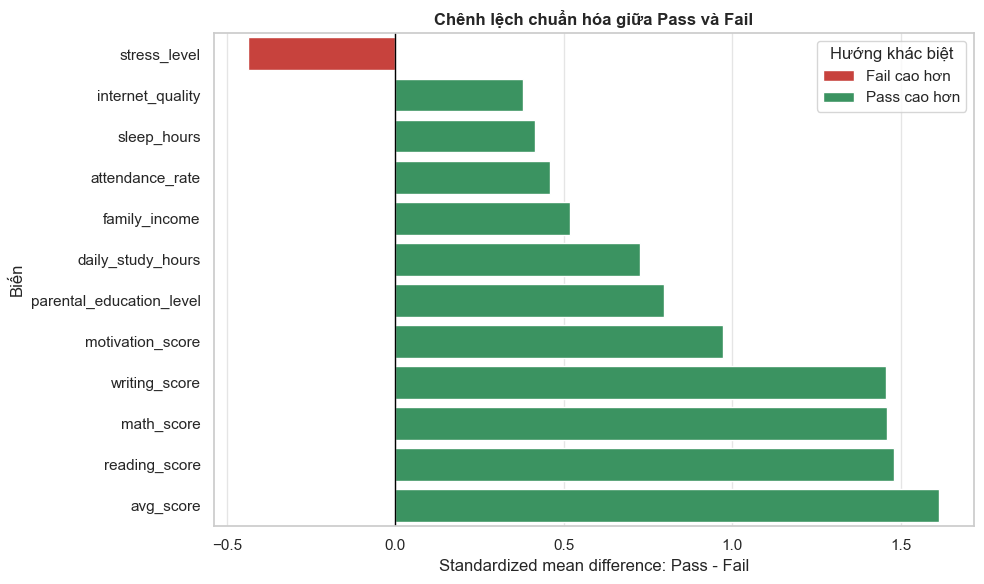

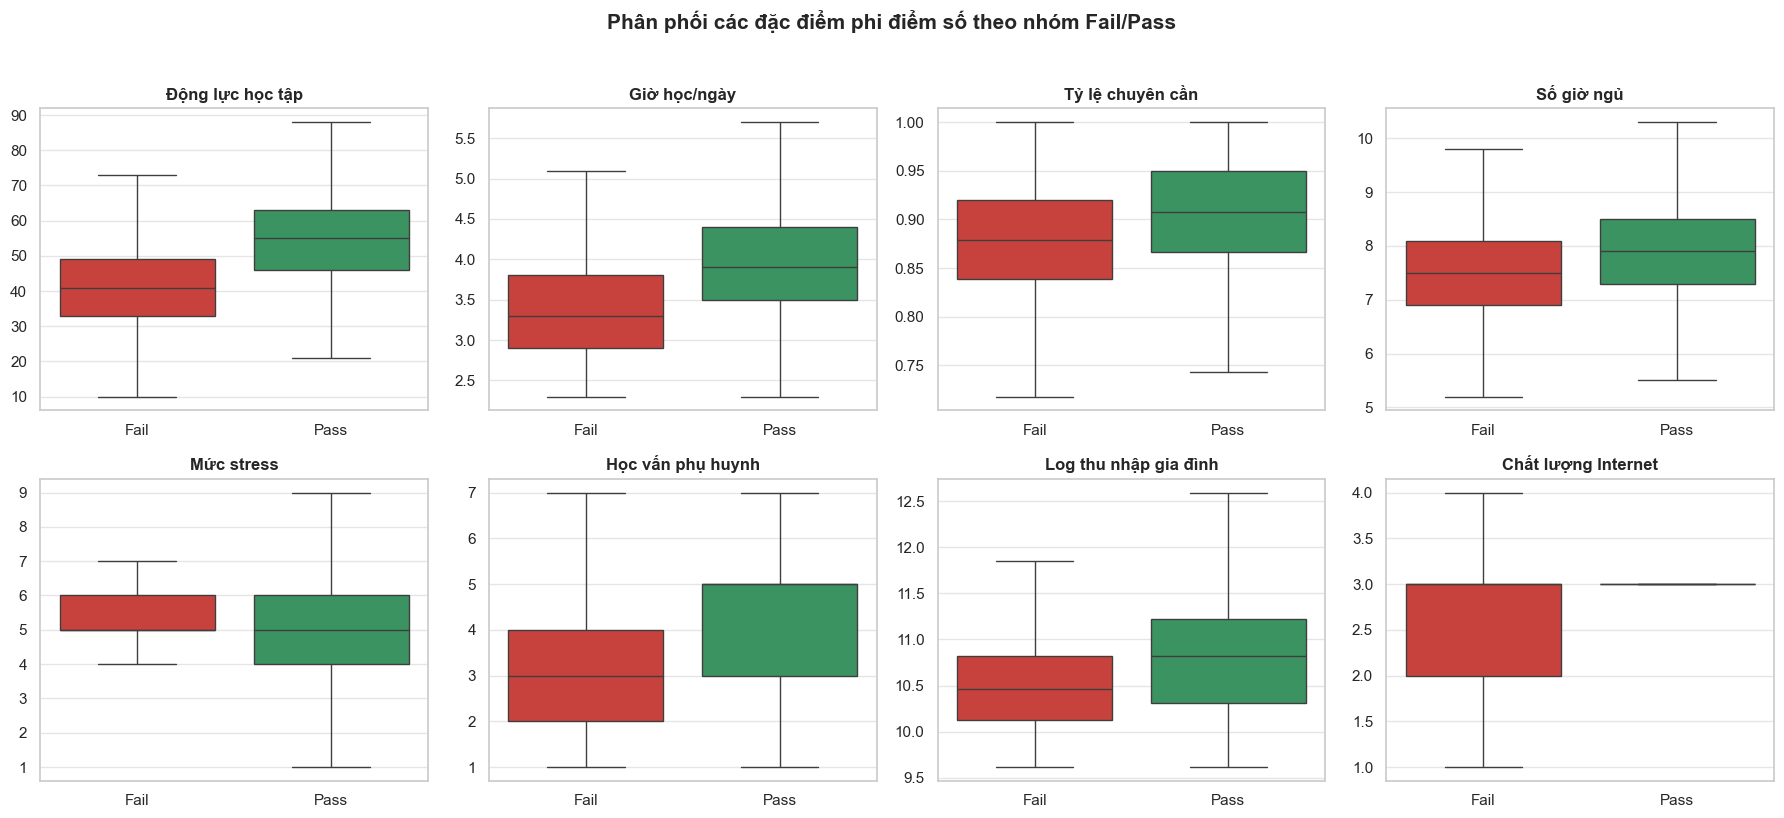

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.0)
palette_pf = {'Pass': '#2ca25f', 'Fail': '#de2d26'}

df_eda = df_clean.copy()
df_eda['target_encoded'] = df_eda['pass_fail'].map({'Pass': 1, 'Fail': 0}).astype(float)

score_cols = ['math_score', 'reading_score', 'writing_score']
df_eda['avg_score'] = df_eda[score_cols].mean(axis=1)
df_eda['log_family_income'] = np.log1p(df_eda['family_income'])

profile_cols = [
    'daily_study_hours', 'attendance_rate', 'sleep_hours', 'stress_level',
    'motivation_score', 'parental_education_level', 'family_income',
    'internet_quality', 'avg_score', 'math_score', 'reading_score', 'writing_score'
]

print('=== THỐNG KÊ THEO NHÓM PASS_FAIL ===')
profile_summary = df_eda.groupby('pass_fail')[profile_cols].agg(['mean', 'median', 'std']).round(2)
display(profile_summary)

mean_by_result = df_eda.groupby('pass_fail')[profile_cols].mean().T
mean_by_result['diff_pass_minus_fail'] = mean_by_result['Pass'] - mean_by_result['Fail']
mean_by_result['pct_diff_vs_fail'] = mean_by_result['diff_pass_minus_fail'] / mean_by_result['Fail'].abs() * 100
mean_by_result = mean_by_result.sort_values('diff_pass_minus_fail', ascending=False).round(3)

print('=== CHÊNH LỆCH TRUNG BÌNH: PASS - FAIL ===')
display(mean_by_result)

std_diff = ((df_eda[df_eda['pass_fail'] == 'Pass'][profile_cols].mean()
             - df_eda[df_eda['pass_fail'] == 'Fail'][profile_cols].mean())
            / df_eda[profile_cols].std()).sort_values()
std_diff_plot = std_diff.reset_index()
std_diff_plot.columns = ['feature', 'standardized_mean_diff']
std_diff_plot['direction'] = np.where(std_diff_plot['standardized_mean_diff'] >= 0, 'Pass cao hơn', 'Fail cao hơn')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=std_diff_plot,
    y='feature', x='standardized_mean_diff', hue='direction',
    palette={'Pass cao hơn': '#2ca25f', 'Fail cao hơn': '#de2d26'}, ax=ax
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Chênh lệch chuẩn hóa giữa Pass và Fail', fontweight='bold')
ax.set_xlabel('Standardized mean difference: Pass - Fail')
ax.set_ylabel('Biến')
ax.legend(title='Hướng khác biệt')
plt.tight_layout()
plt.show()

plot_cols = [
    'motivation_score', 'daily_study_hours', 'attendance_rate', 'sleep_hours',
    'stress_level', 'parental_education_level', 'log_family_income', 'internet_quality'
]
plot_titles = {
    'motivation_score': 'Động lực học tập',
    'daily_study_hours': 'Giờ học/ngày',
    'attendance_rate': 'Tỷ lệ chuyên cần',
    'sleep_hours': 'Số giờ ngủ',
    'stress_level': 'Mức stress',
    'parental_education_level': 'Học vấn phụ huynh',
    'log_family_income': 'Log thu nhập gia đình',
    'internet_quality': 'Chất lượng Internet'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, plot_cols):
    sns.boxplot(
        data=df_eda, x='pass_fail', y=col, hue='pass_fail',
        order=['Fail', 'Pass'], palette=palette_pf, showfliers=False,
        legend=False, ax=ax
    )
    ax.set_title(plot_titles[col], fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.suptitle('Phân phối các đặc điểm phi điểm số theo nhóm Fail/Pass', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight chính:** Nhóm `Pass` thể hiện một hồ sơ học tập tích cực hơn nhóm `Fail` trên nhiều chiều, không chỉ ở điểm số. Khoảng cách lớn nhất nằm ở `math_score`, `reading_score`, `writing_score` và `avg_score`, điều này hợp lý vì các biến điểm số rất gần với cách hình thành nhãn `pass_fail`.

Ở nhóm biến có thể quan sát trước khi có điểm cuối kỳ, nhóm `Pass` thường có `motivation_score`, `daily_study_hours`, `attendance_rate`, `parental_education_level`, `family_income` và `internet_quality` cao hơn, trong khi `stress_level` thấp hơn. Điều này cho thấy rủi ro `Fail` không đến từ một nguyên nhân đơn lẻ, mà là sự kết hợp giữa hành vi học tập, trạng thái tâm lý và điều kiện hỗ trợ từ gia đình/môi trường.

## 3.4. Số giờ học mỗi ngày và khả năng Pass

Câu hỏi ở đây là: học sinh có `daily_study_hours` cao hơn có xu hướng `Pass` nhiều hơn không? Ta kiểm tra bằng phân phối giờ học theo kết quả, tỷ lệ Pass theo khoảng giờ học và tương quan với biến mục tiêu.

=== TỶ LỆ PASS THEO KHOẢNG GIỜ HỌC MỖI NGÀY ===


,study_hours_band,n,pass_rate,avg_score,median_study_hours,pass_rate_pct
0,<=3h,41419,0.27,51.56,2.80,26.61
1,3-3.5h,47610,0.44,58.19,3.30,43.95
2,3.5-4h,51155,0.62,64.47,3.80,62.13
3,4-4.5h,30879,0.72,68.45,4.30,71.73
4,4.5-5h,14681,0.78,71.03,4.80,78.03
5,5-6h,10894,0.83,73.55,5.40,82.53
6,>6h,3362,0.91,80.18,6.50,91.08


=== TƯƠNG QUAN GIỜ HỌC VỚI PASS_FAIL VÀ ĐIỂM TRUNG BÌNH ===


,daily_study_hours,target_encoded,avg_score
daily_study_hours,1.00,0.36,0.45
target_encoded,0.36,1.00,0.80
avg_score,0.45,0.80,1.00


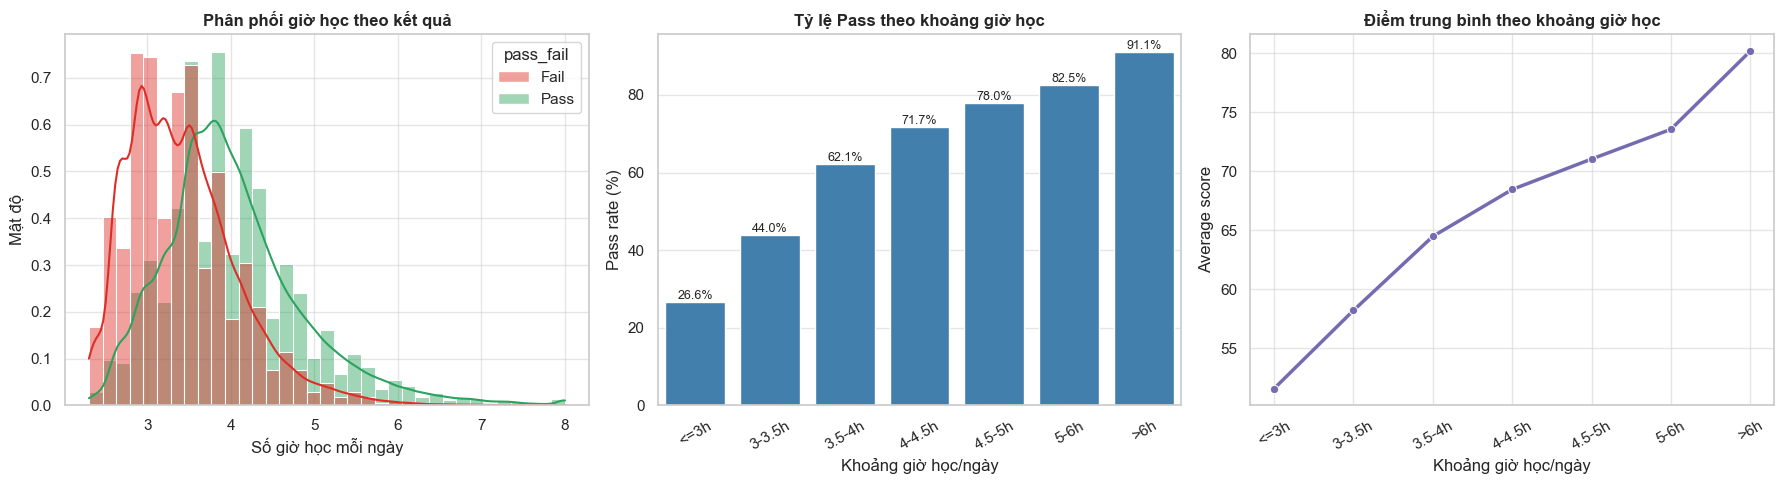

In [12]:
study_bins = [0, 3, 3.5, 4, 4.5, 5, 6, np.inf]
study_labels = ['<=3h', '3-3.5h', '3.5-4h', '4-4.5h', '4.5-5h', '5-6h', '>6h']
df_eda['study_hours_band'] = pd.cut(
    df_eda['daily_study_hours'], bins=study_bins, labels=study_labels, include_lowest=True
)

study_table = (
    df_eda.groupby('study_hours_band', observed=False)
    .agg(
        n=('pass_fail', 'size'),
        pass_rate=('target_encoded', 'mean'),
        avg_score=('avg_score', 'mean'),
        median_study_hours=('daily_study_hours', 'median')
    )
    .reset_index()
)
study_table['pass_rate_pct'] = (study_table['pass_rate'] * 100).round(2)
study_table['avg_score'] = study_table['avg_score'].round(2)

print('=== TỶ LỆ PASS THEO KHOẢNG GIỜ HỌC MỖI NGÀY ===')
display(study_table)

corr_study_target = df_eda[['daily_study_hours', 'target_encoded', 'avg_score']].corr().round(3)
print('=== TƯƠNG QUAN GIỜ HỌC VỚI PASS_FAIL VÀ ĐIỂM TRUNG BÌNH ===')
display(corr_study_target)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(
    data=df_eda, x='daily_study_hours', hue='pass_fail', hue_order=['Fail', 'Pass'],
    palette=palette_pf, bins=35, kde=True, stat='density', common_norm=False,
    alpha=0.45, ax=axes[0]
)
axes[0].set_title('Phân phối giờ học theo kết quả', fontweight='bold')
axes[0].set_xlabel('Số giờ học mỗi ngày')
axes[0].set_ylabel('Mật độ')

sns.barplot(data=study_table, x='study_hours_band', y='pass_rate_pct', color='#3182bd', ax=axes[1])
axes[1].set_title('Tỷ lệ Pass theo khoảng giờ học', fontweight='bold')
axes[1].set_xlabel('Khoảng giờ học/ngày')
axes[1].set_ylabel('Pass rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', fontsize=9)

sns.lineplot(data=study_table, x='study_hours_band', y='avg_score', marker='o', color='#756bb1', linewidth=2.5, ax=axes[2])
axes[2].set_title('Điểm trung bình theo khoảng giờ học', fontweight='bold')
axes[2].set_xlabel('Khoảng giờ học/ngày')
axes[2].set_ylabel('Average score')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Insight chính:** `daily_study_hours` có xu hướng đi cùng khả năng `Pass` cao hơn. Khi chia học sinh theo các khoảng giờ học, tỷ lệ `Pass` và điểm trung bình thường tăng ở các nhóm có thời lượng tự học cao hơn, cho thấy thời gian học mỗi ngày là một tín hiệu hành vi quan trọng.

Tuy nhiên, biến này nên được hiểu là tín hiệu về mức độ đầu tư học tập hơn là quan hệ nhân quả tuyệt đối. Một học sinh học nhiều giờ có thể đồng thời có động lực cao hơn, chuyên cần tốt hơn hoặc nhận được hỗ trợ học tập tốt hơn; vì vậy `daily_study_hours` nên được kết hợp với `motivation_score`, `attendance_rate`, `stress_level` và `private_tutoring` khi xây dựng mô hình.

## 3.5. Attendance rate liên quan thế nào đến điểm số và Pass/Fail?

`attendance_rate` là tín hiệu hành vi quan trọng vì có thể quan sát trước kết quả cuối kỳ. Phần này kiểm tra liệu chuyên cần cao hơn có đi cùng điểm số tốt hơn và tỷ lệ `Pass` cao hơn hay không.

=== TỶ LỆ PASS VÀ ĐIỂM SỐ THEO NHÓM ATTENDANCE_RATE ===


,attendance_band,n,min_attendance,max_attendance,pass_rate,avg_score,math_score,reading_score,writing_score,attendance_band_label,pass_rate_pct
0,"(0.584, 0.843]",40640,0.58,0.84,0.39,55.95,56.93,56.04,54.88,"(0.584, 0.843]",38.98
1,"(0.843, 0.879]",39540,0.84,0.88,0.48,59.66,60.52,59.90,58.57,"(0.843, 0.879]",48.11
2,"(0.879, 0.911]",40621,0.88,0.91,0.55,62.11,62.93,62.44,60.97,"(0.879, 0.911]",54.72
3,"(0.911, 0.948]",39935,0.91,0.95,0.61,64.57,65.34,65.05,63.33,"(0.911, 0.948]",60.99
4,"(0.948, 1.0]",39264,0.95,1.00,0.71,68.69,69.32,69.32,67.43,"(0.948, 1.0]",71.16


=== TƯƠNG QUAN ATTENDANCE_RATE VỚI PASS_FAIL VÀ ĐIỂM SỐ ===


,target_encoded,avg_score,math_score,reading_score,writing_score
attendance_rate,0.23,0.28,0.26,0.26,0.26


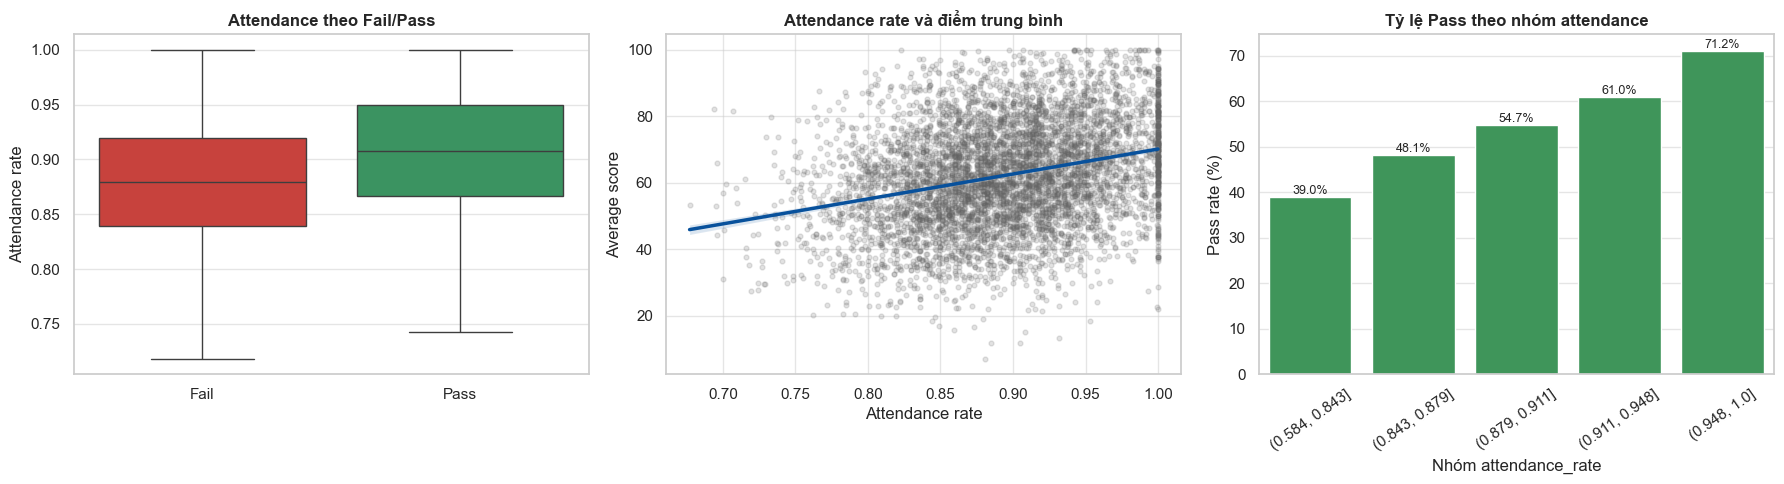

In [13]:
df_eda['attendance_band'] = pd.qcut(df_eda['attendance_rate'], q=5, duplicates='drop')

attendance_table = (
    df_eda.groupby('attendance_band', observed=False)
    .agg(
        n=('pass_fail', 'size'),
        min_attendance=('attendance_rate', 'min'),
        max_attendance=('attendance_rate', 'max'),
        pass_rate=('target_encoded', 'mean'),
        avg_score=('avg_score', 'mean'),
        math_score=('math_score', 'mean'),
        reading_score=('reading_score', 'mean'),
        writing_score=('writing_score', 'mean')
    )
    .reset_index()
)
attendance_table['attendance_band_label'] = attendance_table['attendance_band'].astype(str)
attendance_table['pass_rate_pct'] = (attendance_table['pass_rate'] * 100).round(2)
for col in ['min_attendance', 'max_attendance', 'avg_score', 'math_score', 'reading_score', 'writing_score']:
    attendance_table[col] = attendance_table[col].round(3)

print('=== TỶ LỆ PASS VÀ ĐIỂM SỐ THEO NHÓM ATTENDANCE_RATE ===')
display(attendance_table)

attendance_corr = df_eda[['attendance_rate', 'target_encoded', 'avg_score'] + score_cols].corr().round(3)
print('=== TƯƠNG QUAN ATTENDANCE_RATE VỚI PASS_FAIL VÀ ĐIỂM SỐ ===')
display(attendance_corr.loc[['attendance_rate'], ['target_encoded', 'avg_score'] + score_cols])

sample_att = df_eda.sample(n=min(6000, len(df_eda)), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(
    data=df_eda, x='pass_fail', y='attendance_rate', hue='pass_fail',
    order=['Fail', 'Pass'], palette=palette_pf, showfliers=False,
    legend=False, ax=axes[0]
)
axes[0].set_title('Attendance theo Fail/Pass', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Attendance rate')

sns.regplot(
    data=sample_att, x='attendance_rate', y='avg_score',
    scatter_kws={'alpha': 0.18, 's': 12, 'color': '#636363'},
    line_kws={'color': '#08519c', 'linewidth': 2.5}, ax=axes[1]
)
axes[1].set_title('Attendance rate và điểm trung bình', fontweight='bold')
axes[1].set_xlabel('Attendance rate')
axes[1].set_ylabel('Average score')

sns.barplot(data=attendance_table, x='attendance_band_label', y='pass_rate_pct', color='#31a354', ax=axes[2])
axes[2].set_title('Tỷ lệ Pass theo nhóm attendance', fontweight='bold')
axes[2].set_xlabel('Nhóm attendance_rate')
axes[2].set_ylabel('Pass rate (%)')
axes[2].tick_params(axis='x', rotation=35)
axes[2].bar_label(axes[2].containers[0], fmt='%.1f%%', fontsize=9)
plt.tight_layout()
plt.show()

**Insight chính:** `attendance_rate` có quan hệ dương với cả điểm số và kết quả `pass_fail`. Các nhóm có tỷ lệ chuyên cần cao thường đạt `avg_score` cao hơn và có tỷ lệ `Pass` lớn hơn, phản ánh vai trò của việc tham gia lớp học đều đặn đối với kết quả học tập.

Dù tín hiệu của attendance thường không mạnh bằng nhóm điểm số hay `motivation_score`, đây là biến rất hữu ích cho bài toán cảnh báo sớm vì có thể theo dõi trước kỳ thi. Học sinh có attendance thấp nên được xem là nhóm cần can thiệp sớm, đặc biệt nếu đồng thời có động lực thấp hoặc stress cao.

## 3.6. Sleep hours, stress level và điểm số

Phần này xem xét chuỗi quan hệ mô tả: `sleep_hours` thay đổi như thế nào theo `stress_level`, và `stress_level` liên hệ ra sao với điểm số/kết quả `Pass`. Cách đọc phù hợp là insight mô tả, không kết luận nhân quả tuyệt đối.

=== STRESS, ĐIỂM SỐ VÀ PASS RATE THEO KHOẢNG GIỜ NGỦ ===


,sleep_band,n,stress_mean,stress_median,avg_score,pass_rate,pass_rate_pct
0,<=5h,382,6.37,6.00,47.10,0.18,18.06
1,5-6h,6974,5.98,6.00,51.90,0.30,30.20
2,6-7h,39634,5.57,6.00,57.73,0.44,43.70
3,7-8h,82776,5.16,5.00,61.58,0.53,53.03
4,8-9h,55669,4.74,5.00,65.59,0.63,63.36
5,9-10h,13416,4.34,4.00,69.39,0.73,72.84
6,10-12h,1149,3.95,4.00,73.39,0.83,82.94


=== TƯƠNG QUAN GIỮA SLEEP, STRESS, ĐIỂM SỐ VÀ PASS_FAIL ===


,stress_level,avg_score,target_encoded,math_score,reading_score,writing_score
sleep_hours,-0.29,0.26,0.21,0.25,0.22,0.24
stress_level,1.00,-0.27,-0.22,-0.26,-0.22,-0.26


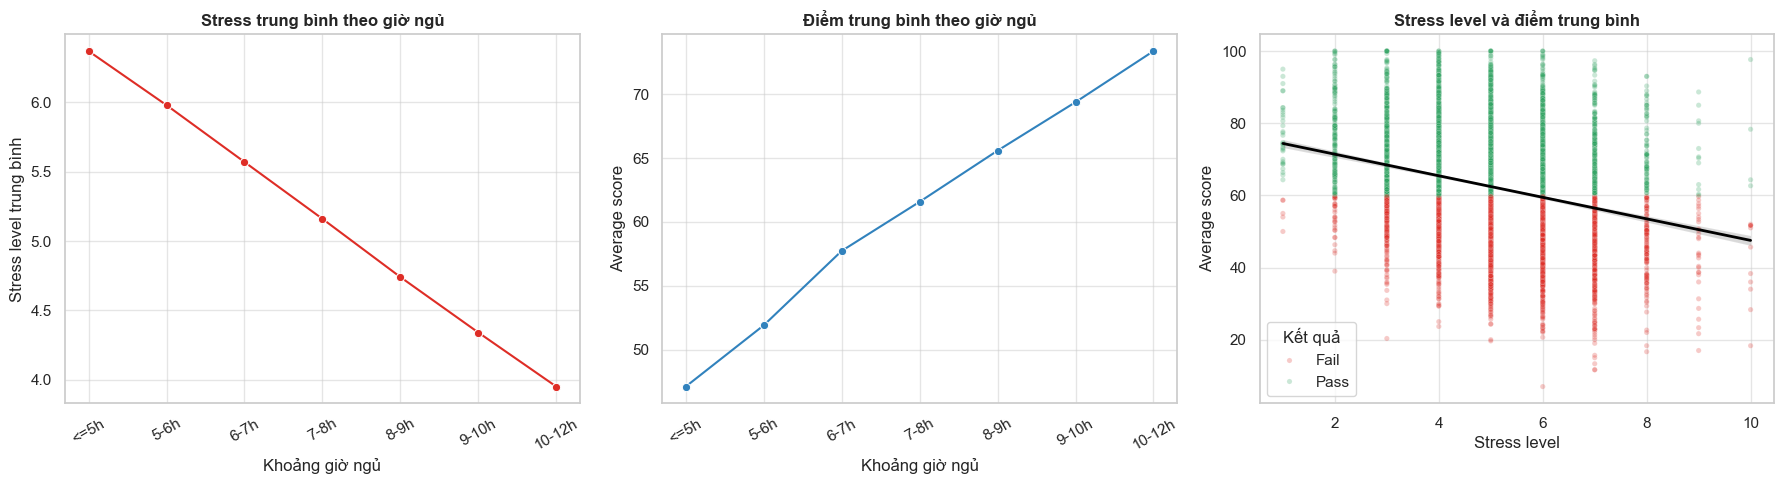

In [14]:
sleep_bins = [0, 5, 6, 7, 8, 9, 10, 12]
sleep_labels = ['<=5h', '5-6h', '6-7h', '7-8h', '8-9h', '9-10h', '10-12h']
df_eda['sleep_band'] = pd.cut(df_eda['sleep_hours'], bins=sleep_bins, labels=sleep_labels, include_lowest=True)

sleep_table = (
    df_eda.groupby('sleep_band', observed=False)
    .agg(
        n=('pass_fail', 'size'),
        stress_mean=('stress_level', 'mean'),
        stress_median=('stress_level', 'median'),
        avg_score=('avg_score', 'mean'),
        pass_rate=('target_encoded', 'mean')
    )
    .reset_index()
)
sleep_table['pass_rate_pct'] = (sleep_table['pass_rate'] * 100).round(2)
for col in ['stress_mean', 'stress_median', 'avg_score']:
    sleep_table[col] = sleep_table[col].round(2)

print('=== STRESS, ĐIỂM SỐ VÀ PASS RATE THEO KHOẢNG GIỜ NGỦ ===')
display(sleep_table)

sleep_stress_corr = df_eda[['sleep_hours', 'stress_level', 'avg_score', 'target_encoded'] + score_cols].corr().round(3)
print('=== TƯƠNG QUAN GIỮA SLEEP, STRESS, ĐIỂM SỐ VÀ PASS_FAIL ===')
display(sleep_stress_corr.loc[['sleep_hours', 'stress_level'], ['stress_level', 'avg_score', 'target_encoded'] + score_cols])

sample_sleep = df_eda.sample(n=min(6000, len(df_eda)), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=sleep_table, x='sleep_band', y='stress_mean', marker='o', color='#de2d26', ax=axes[0])
axes[0].set_title('Stress trung bình theo giờ ngủ', fontweight='bold')
axes[0].set_xlabel('Khoảng giờ ngủ')
axes[0].set_ylabel('Stress level trung bình')
axes[0].tick_params(axis='x', rotation=30)

sns.lineplot(data=sleep_table, x='sleep_band', y='avg_score', marker='o', color='#3182bd', ax=axes[1])
axes[1].set_title('Điểm trung bình theo giờ ngủ', fontweight='bold')
axes[1].set_xlabel('Khoảng giờ ngủ')
axes[1].set_ylabel('Average score')
axes[1].tick_params(axis='x', rotation=30)

sns.scatterplot(
    data=sample_sleep, x='stress_level', y='avg_score', hue='pass_fail',
    hue_order=['Fail', 'Pass'], palette=palette_pf, alpha=0.25, s=14, ax=axes[2]
)
sns.regplot(data=sample_sleep, x='stress_level', y='avg_score', scatter=False, color='black', line_kws={'linewidth': 2}, ax=axes[2])
axes[2].set_title('Stress level và điểm trung bình', fontweight='bold')
axes[2].set_xlabel('Stress level')
axes[2].set_ylabel('Average score')
axes[2].legend(title='Kết quả')
plt.tight_layout()
plt.show()

**Insight chính:** `sleep_hours` liên quan đến kết quả học tập theo hướng gián tiếp hơn là trực tiếp. Nhóm ngủ cân bằng thường có mức stress thấp hơn và điểm trung bình ổn định hơn, trong khi `stress_level` cao có xu hướng đi cùng điểm số thấp hơn và khả năng `Fail` cao hơn.

Điểm đáng chú ý là stress đóng vai trò như một biến rủi ro tâm lý: khi stress tăng, hiệu quả học tập có thể giảm dù học sinh vẫn có thời gian học. Vì vậy, trong mô hình cảnh báo sớm, `sleep_hours` và `stress_level` nên được đọc cùng nhau để nhận diện nhóm học sinh có nguy cơ suy giảm kết quả do mất cân bằng sinh hoạt/tâm lý.

## 3.7. Motivation score và khả năng Pass

`motivation_score` đo mức động lực học tập. Phần này kiểm tra liệu động lực cao hơn có đi cùng tỷ lệ `Pass` cao hơn, đồng thời xem động lực liên hệ thế nào với điểm trung bình và thời lượng học.

=== TỶ LỆ PASS THEO NHÓM MOTIVATION_SCORE ===


,motivation_band,n,pass_rate,avg_score,daily_study_hours,stress_level,pass_rate_pct
0,0-20,3800,0.07,39.91,3.46,5.64,6.79
1,21-40,51989,0.25,51.41,3.56,5.30,25.42
2,41-60,106060,0.58,63.35,3.77,5.08,58.40
3,61-80,36172,0.89,75.12,3.98,4.84,88.50
4,81-100,1979,0.99,86.26,4.17,4.56,99.24


=== TƯƠNG QUAN MOTIVATION_SCORE VỚI PASS_FAIL, ĐIỂM, GIỜ HỌC VÀ STRESS ===


,motivation_score,target_encoded,avg_score,daily_study_hours,stress_level
motivation_score,1.00,0.48,0.60,0.19,-0.13


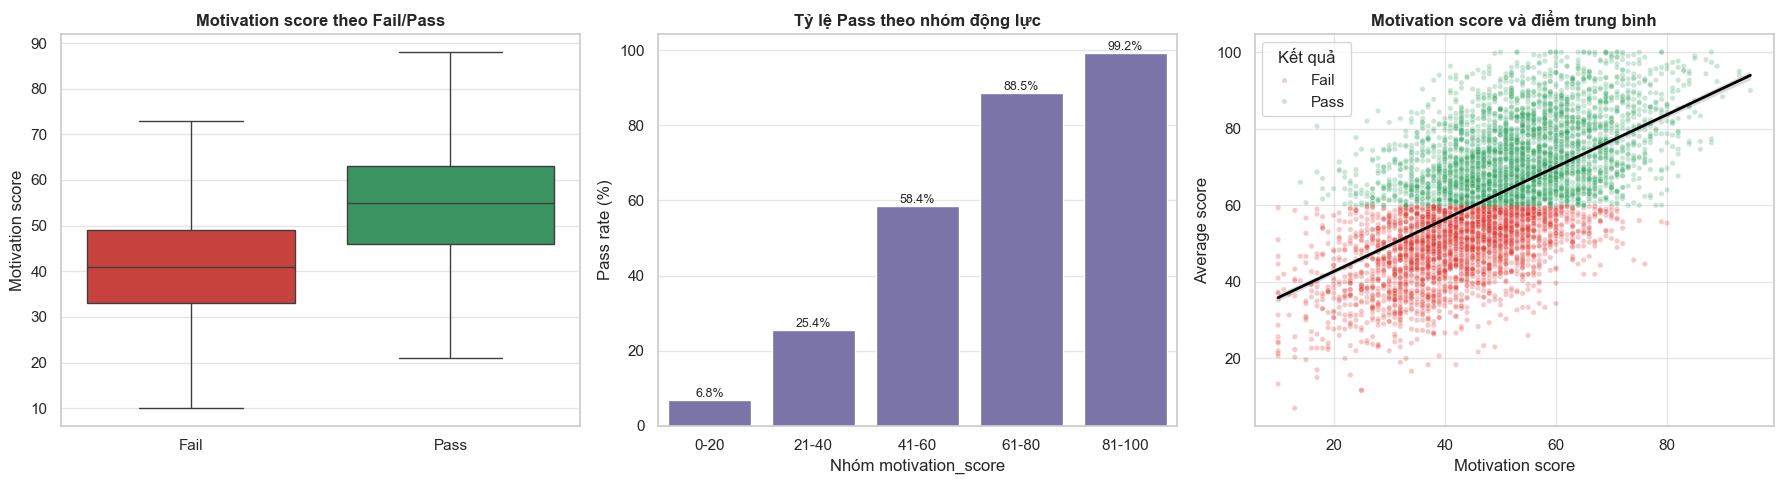

In [15]:
motivation_bins = [0, 20, 40, 60, 80, 100]
motivation_labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
df_eda['motivation_band'] = pd.cut(df_eda['motivation_score'], bins=motivation_bins, labels=motivation_labels, include_lowest=True)

motivation_table = (
    df_eda.groupby('motivation_band', observed=False)
    .agg(
        n=('pass_fail', 'size'),
        pass_rate=('target_encoded', 'mean'),
        avg_score=('avg_score', 'mean'),
        daily_study_hours=('daily_study_hours', 'mean'),
        stress_level=('stress_level', 'mean')
    )
    .reset_index()
)
motivation_table['pass_rate_pct'] = (motivation_table['pass_rate'] * 100).round(2)
for col in ['avg_score', 'daily_study_hours', 'stress_level']:
    motivation_table[col] = motivation_table[col].round(2)

print('=== TỶ LỆ PASS THEO NHÓM MOTIVATION_SCORE ===')
display(motivation_table)

motivation_corr = df_eda[['motivation_score', 'target_encoded', 'avg_score', 'daily_study_hours', 'stress_level']].corr().round(3)
print('=== TƯƠNG QUAN MOTIVATION_SCORE VỚI PASS_FAIL, ĐIỂM, GIỜ HỌC VÀ STRESS ===')
display(motivation_corr.loc[['motivation_score']])

sample_motivation = df_eda.sample(n=min(6000, len(df_eda)), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(
    data=df_eda, x='pass_fail', y='motivation_score', hue='pass_fail',
    order=['Fail', 'Pass'], palette=palette_pf, showfliers=False,
    legend=False, ax=axes[0]
)
axes[0].set_title('Motivation score theo Fail/Pass', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Motivation score')

sns.barplot(data=motivation_table, x='motivation_band', y='pass_rate_pct', color='#756bb1', ax=axes[1])
axes[1].set_title('Tỷ lệ Pass theo nhóm động lực', fontweight='bold')
axes[1].set_xlabel('Nhóm motivation_score')
axes[1].set_ylabel('Pass rate (%)')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', fontsize=9)

sns.scatterplot(
    data=sample_motivation, x='motivation_score', y='avg_score', hue='pass_fail',
    hue_order=['Fail', 'Pass'], palette=palette_pf, alpha=0.25, s=14, ax=axes[2]
)
sns.regplot(data=sample_motivation, x='motivation_score', y='avg_score', scatter=False, color='black', line_kws={'linewidth': 2}, ax=axes[2])
axes[2].set_title('Motivation score và điểm trung bình', fontweight='bold')
axes[2].set_xlabel('Motivation score')
axes[2].set_ylabel('Average score')
axes[2].legend(title='Kết quả')
plt.tight_layout()
plt.show()

**Insight chính:** `motivation_score` là một trong những biến phi điểm số có tín hiệu mạnh nhất với `pass_fail`. Tỷ lệ `Pass` tăng rõ khi chuyển từ nhóm động lực thấp sang nhóm động lực cao, đồng thời điểm trung bình cũng có xu hướng tăng theo `motivation_score`.

Biến này có ý nghĩa thực tiễn tốt vì nó phản ánh thái độ học tập trước khi kết quả cuối kỳ xuất hiện. Khi động lực cao đi cùng số giờ học cao hơn và stress thấp hơn, khả năng `Pass` trở nên rõ ràng hơn; ngược lại, động lực thấp là một dấu hiệu cảnh báo sớm cần ưu tiên theo dõi.

## 3.8. Private tutoring và tỷ lệ Pass

Phần này so sánh nhóm có học thêm/gia sư (`private_tutoring = True`) với nhóm không học thêm. Ta xem đồng thời tỷ lệ Pass và điểm trung bình để tránh chỉ kết luận dựa trên một chỉ số.

=== SO SÁNH NHÓM HỌC THÊM/GIA SƯ VÀ KHÔNG HỌC THÊM ===


,tutoring_group,n,pass_rate,avg_score,math_score,reading_score,writing_score,motivation_score,daily_study_hours,pass_rate_pct
0,Không học thêm,145236,0.43,57.48,58.34,57.76,56.35,48.15,3.72,43.09
1,Có học thêm,54764,0.85,74.56,75.25,75.11,73.33,49.71,3.84,85.46


=== CƠ CẤU PASS/FAIL THEO PRIVATE_TUTORING (%) ===


pass_fail,Fail,Pass
tutoring_group,,
Không học thêm,56.91,43.09
Có học thêm,14.54,85.46


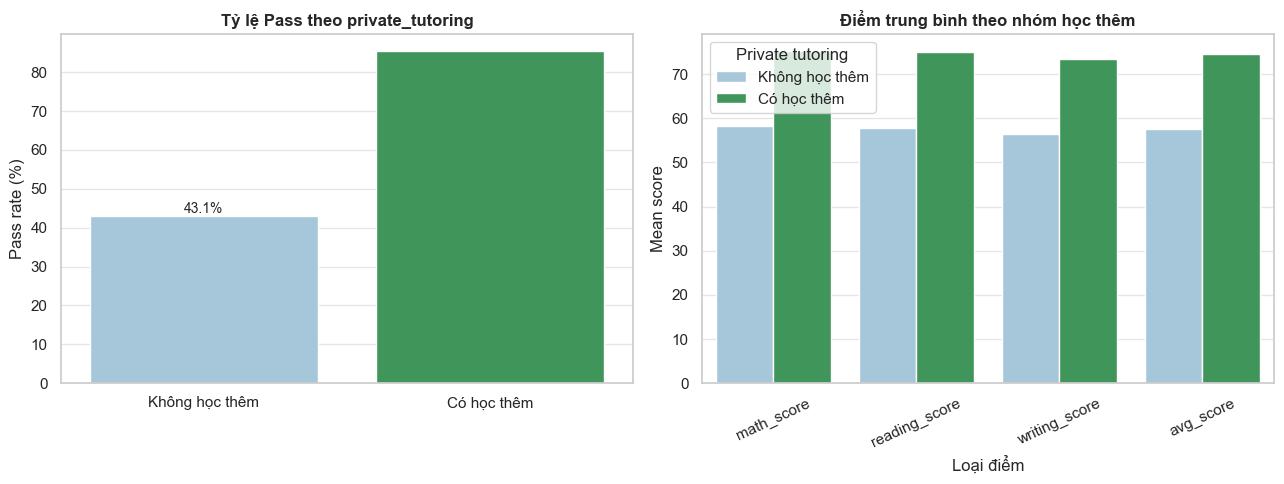

In [16]:
df_eda['tutoring_group'] = df_eda['private_tutoring'].map({True: 'Có học thêm', False: 'Không học thêm'})

tutoring_table = (
    df_eda.groupby('tutoring_group')
    .agg(
        n=('pass_fail', 'size'),
        pass_rate=('target_encoded', 'mean'),
        avg_score=('avg_score', 'mean'),
        math_score=('math_score', 'mean'),
        reading_score=('reading_score', 'mean'),
        writing_score=('writing_score', 'mean'),
        motivation_score=('motivation_score', 'mean'),
        daily_study_hours=('daily_study_hours', 'mean')
    )
    .reindex(['Không học thêm', 'Có học thêm'])
    .reset_index()
)
tutoring_table['pass_rate_pct'] = (tutoring_table['pass_rate'] * 100).round(2)
for col in ['avg_score', 'math_score', 'reading_score', 'writing_score', 'motivation_score', 'daily_study_hours']:
    tutoring_table[col] = tutoring_table[col].round(2)

print('=== SO SÁNH NHÓM HỌC THÊM/GIA SƯ VÀ KHÔNG HỌC THÊM ===')
display(tutoring_table)

cross_tutoring = pd.crosstab(df_eda['tutoring_group'], df_eda['pass_fail'], normalize='index').reindex(['Không học thêm', 'Có học thêm']) * 100
print('=== CƠ CẤU PASS/FAIL THEO PRIVATE_TUTORING (%) ===')
display(cross_tutoring.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(
    data=tutoring_table, x='tutoring_group', y='pass_rate_pct',
    hue='tutoring_group', palette=['#9ecae1', '#31a354'],
    legend=False, ax=axes[0]
)
axes[0].set_title('Tỷ lệ Pass theo private_tutoring', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Pass rate (%)')
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%', fontsize=10)

score_long = tutoring_table.melt(id_vars='tutoring_group', value_vars=score_cols + ['avg_score'], var_name='score_type', value_name='score_mean')
sns.barplot(data=score_long, x='score_type', y='score_mean', hue='tutoring_group', palette=['#9ecae1', '#31a354'], ax=axes[1])
axes[1].set_title('Điểm trung bình theo nhóm học thêm', fontweight='bold')
axes[1].set_xlabel('Loại điểm')
axes[1].set_ylabel('Mean score')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Private tutoring')
plt.tight_layout()
plt.show()

**Insight chính:** Nhóm có `private_tutoring` thường có lợi thế hơn về tỷ lệ `Pass` và điểm trung bình so với nhóm không học thêm. Điều này gợi ý rằng gia sư/học thêm có thể đóng vai trò như một nguồn hỗ trợ học tập bổ sung, đặc biệt với các học sinh cần củng cố kiến thức ngoài giờ học chính.

Tuy vậy, không nên diễn giải học thêm là nguyên nhân duy nhất làm tăng khả năng `Pass`. Nhóm có học thêm cũng có thể khác biệt về thu nhập gia đình, học vấn phụ huynh, động lực học tập hoặc mức độ quan tâm của gia đình. Do đó, `private_tutoring` nên được xem là biến hỗ trợ mạnh, nhưng cần kiểm chứng thêm trong mô hình đa biến.

## 3.9. Tương quan giữa math_score, reading_score và writing_score

Ba điểm số có thể cùng phản ánh năng lực học thuật chung. Nếu chúng tương quan cao với nhau, mô hình dùng cả ba biến sẽ có nhiều thông tin trùng lặp, đặc biệt quan trọng với các mô hình tuyến tính.

=== MA TRẬN TƯƠNG QUAN GIỮA BA ĐIỂM SỐ ===


,math_score,reading_score,writing_score
math_score,1.00,0.74,0.73
reading_score,0.74,1.00,0.74
writing_score,0.73,0.74,1.00


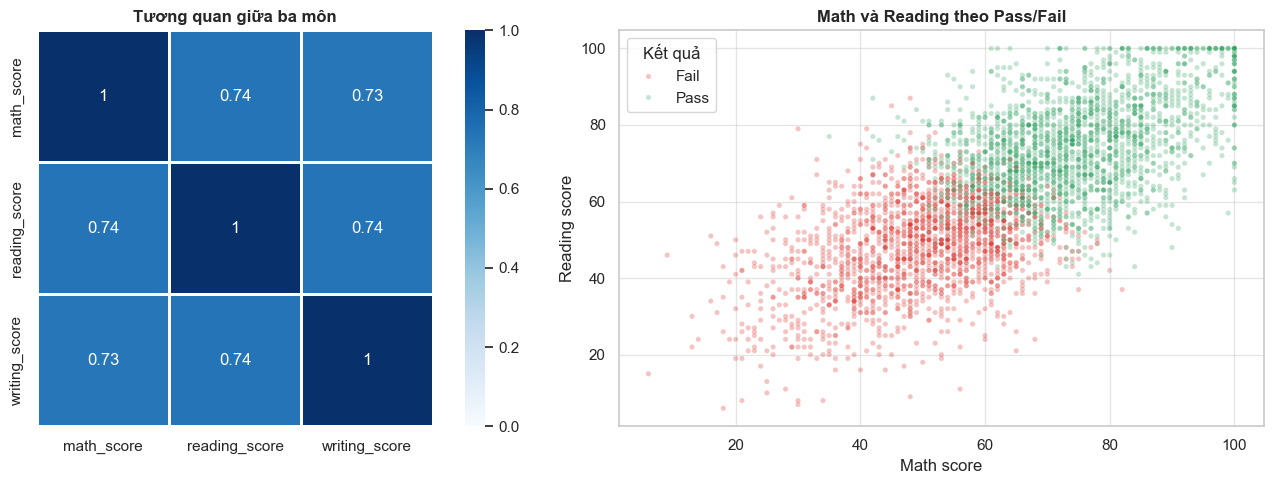

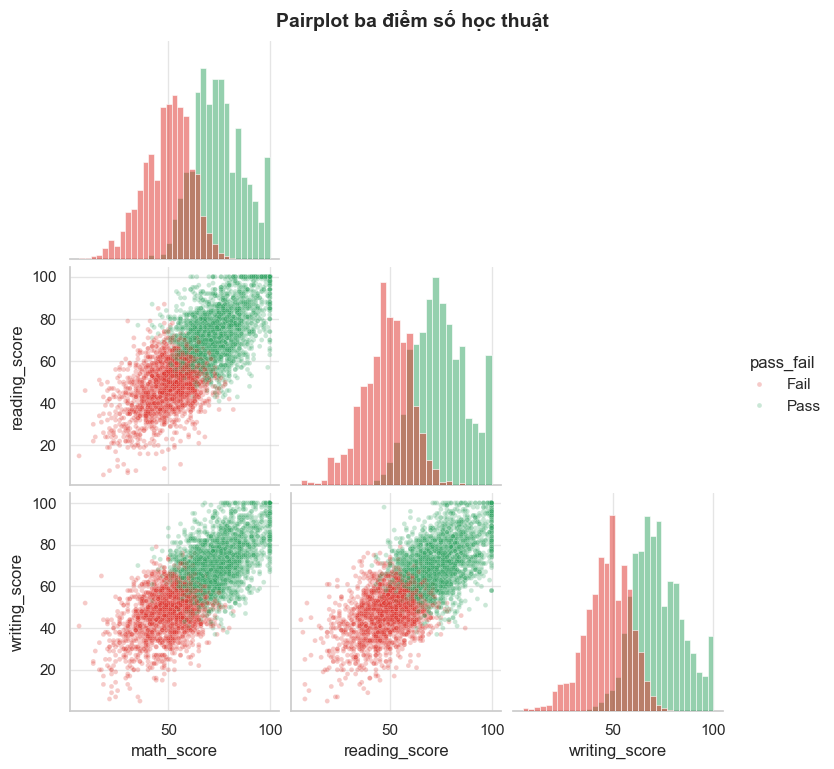

In [17]:
score_corr = df_eda[score_cols].corr().round(3)
print('=== MA TRẬN TƯƠNG QUAN GIỮA BA ĐIỂM SỐ ===')
display(score_corr)

sample_scores = df_eda.sample(n=min(4000, len(df_eda)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(score_corr, annot=True, cmap='Blues', vmin=0, vmax=1, linewidths=0.8, square=True, ax=axes[0])
axes[0].set_title('Tương quan giữa ba môn', fontweight='bold')

sns.scatterplot(
    data=sample_scores, x='math_score', y='reading_score', hue='pass_fail',
    hue_order=['Fail', 'Pass'], palette=palette_pf, alpha=0.28, s=14, ax=axes[1]
)
axes[1].set_title('Math và Reading theo Pass/Fail', fontweight='bold')
axes[1].set_xlabel('Math score')
axes[1].set_ylabel('Reading score')
axes[1].legend(title='Kết quả')
plt.tight_layout()
plt.show()

sns.pairplot(
    sample_scores[score_cols + ['pass_fail']],
    hue='pass_fail', hue_order=['Fail', 'Pass'], palette=palette_pf,
    corner=True, plot_kws={'alpha': 0.25, 's': 12}, diag_kind='hist'
)
plt.suptitle('Pairplot ba điểm số học thuật', y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Insight chính:** `math_score`, `reading_score` và `writing_score` có tương quan dương mạnh với nhau, cho thấy ba môn cùng phản ánh một nền năng lực học thuật chung. Học sinh giỏi ở một môn thường có xu hướng đạt điểm tốt ở các môn còn lại, thay vì ba điểm số biến động hoàn toàn độc lập.

Với mô hình dự đoán sau khi đã có điểm, ba biến này là nhóm tín hiệu rất mạnh cho `pass_fail`. Tuy nhiên, với mô hình cảnh báo sớm trước kỳ thi, chúng có nguy cơ tạo rò rỉ thông tin vì quá gần với kết quả cuối cùng. Nếu dùng mô hình tuyến tính, tương quan cao giữa ba điểm cũng cần được chú ý vì có thể gây đa cộng tuyến; một lựa chọn gọn hơn là dùng `avg_score` hoặc kiểm soát bằng regularization.

## 3.10. Tương quan định hướng biến mục tiêu

Sau khi phân tích từng câu hỏi, phần này gom các biến lại để xem tín hiệu nào liên hệ mạnh nhất với `pass_fail`. Bảng đầu tiên bao gồm cả điểm số; bảng thứ hai loại ba điểm số để phục vụ kịch bản cảnh báo sớm.

=== CÁC CỘT GENDER SAU ONE-HOT ENCODING ===
['gender_Female', 'gender_Male']
=== TƯƠNG QUAN VỚI PASS_FAIL: BAO GỒM CẢ ĐIỂM SỐ ===


,corr_with_pass_fail,abs_corr
avg_score,0.80,0.80
reading_score,0.74,0.74
math_score,0.73,0.73
writing_score,0.72,0.72
motivation_score,0.48,0.48
parental_education_level,0.40,0.40
private_tutoring_encoded,0.38,0.38
daily_study_hours,0.36,0.36
family_income,0.26,0.26
attendance_rate,0.23,0.23


=== TƯƠNG QUAN VỚI PASS_FAIL: LOẠI NHÓM ĐIỂM SỐ ĐỂ CẢNH BÁO SỚM ===


,corr_with_pass_fail,abs_corr
motivation_score,0.48,0.48
parental_education_level,0.40,0.40
private_tutoring_encoded,0.38,0.38
daily_study_hours,0.36,0.36
family_income,0.26,0.26
attendance_rate,0.23,0.23
stress_level,-0.22,0.22
sleep_hours,0.21,0.21
internet_quality,0.19,0.19
age,-0.06,0.06


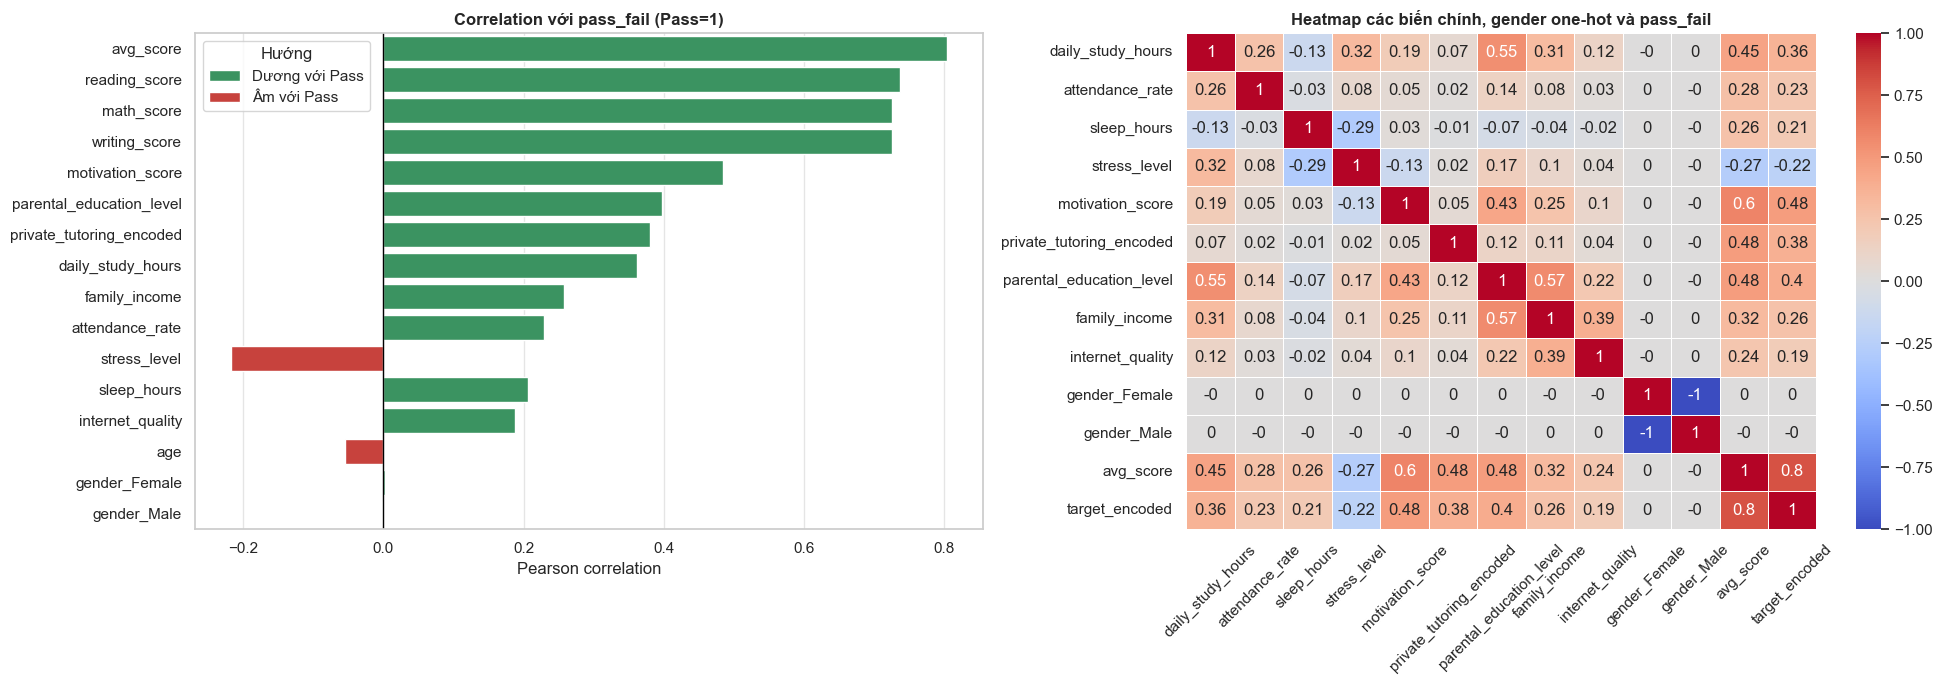

In [19]:
df_corr = df_eda.copy()
df_corr['private_tutoring_encoded'] = df_corr['private_tutoring'].astype(float)

# One-hot encode gender để đưa vào correlation/heatmap.
# Cách này minh bạch hơn gender_encoded 0/1 vì không áp đặt thứ tự giả giữa các nhóm giới tính.
if 'gender' in df_corr.columns:
    gender_dummies = pd.get_dummies(
        df_corr['gender'].astype('string').fillna('missing'),
        prefix='gender',
        dtype=float
    )
    df_corr = pd.concat([df_corr, gender_dummies], axis=1)
    gender_dummy_cols = gender_dummies.columns.tolist()
else:
    gender_dummy_cols = []

corr_features = [
    'age', *gender_dummy_cols, 'parental_education_level', 'family_income',
    'daily_study_hours', 'attendance_rate', 'sleep_hours', 'stress_level',
    'motivation_score', 'private_tutoring_encoded', 'internet_quality',
    'math_score', 'reading_score', 'writing_score', 'avg_score', 'target_encoded'
]
corr_features = [col for col in corr_features if col in df_corr.columns]

corr_matrix = df_corr[corr_features].corr()
target_corr = corr_matrix['target_encoded'].drop('target_encoded').dropna().to_frame('corr_with_pass_fail')
target_corr['abs_corr'] = target_corr['corr_with_pass_fail'].abs()
target_corr = target_corr.sort_values('abs_corr', ascending=False).round(3)
early_warning_corr = target_corr.drop(index=score_cols + ['avg_score'], errors='ignore')

print('=== CÁC CỘT GENDER SAU ONE-HOT ENCODING ===')
print(gender_dummy_cols)
print('=== TƯƠNG QUAN VỚI PASS_FAIL: BAO GỒM CẢ ĐIỂM SỐ ===')
display(target_corr)
print('=== TƯƠNG QUAN VỚI PASS_FAIL: LOẠI NHÓM ĐIỂM SỐ ĐỂ CẢNH BÁO SỚM ===')
display(early_warning_corr)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
plot_target_corr = target_corr.reset_index().rename(columns={'index': 'feature'})
plot_target_corr['direction'] = np.where(plot_target_corr['corr_with_pass_fail'] >= 0, 'Dương với Pass', 'Âm với Pass')
sns.barplot(
    data=plot_target_corr, y='feature', x='corr_with_pass_fail', hue='direction',
    palette={'Dương với Pass': '#2ca25f', 'Âm với Pass': '#de2d26'}, ax=axes[0]
)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Correlation với pass_fail (Pass=1)', fontweight='bold')
axes[0].set_xlabel('Pearson correlation')
axes[0].set_ylabel('')
axes[0].legend(title='Hướng')

heatmap_cols = [
    'daily_study_hours', 'attendance_rate', 'sleep_hours', 'stress_level',
    'motivation_score', 'private_tutoring_encoded', 'parental_education_level',
    'family_income', 'internet_quality', *gender_dummy_cols, 'avg_score', 'target_encoded'
]
heatmap_cols = [col for col in heatmap_cols if col in df_corr.columns]

sns.heatmap(
    df_corr[heatmap_cols].corr().round(2),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    ax=axes[1]
)
axes[1].set_title('Heatmap các biến chính, gender one-hot và pass_fail', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()


**Insight chính:** Khi giữ lại nhóm điểm số, các biến `math_score`, `reading_score`, `writing_score` và `avg_score` chi phối mạnh nhất mối liên hệ với `pass_fail`. Điều này xác nhận rằng nhãn Đậu/Rớt gắn rất chặt với kết quả học thuật cuối kỳ.

Khi loại nhóm điểm số để phục vụ cảnh báo sớm, các tín hiệu đáng chú ý chuyển sang `motivation_score`, `daily_study_hours`, `attendance_rate`, `private_tutoring`, `parental_education_level`, `family_income`, `sleep_hours`, `stress_level` và `internet_quality`. `gender` đã được one-hot encode trong bảng/heatmap để kiểm tra minh bạch, nhưng nếu các cột `gender_*` có correlation gần 0 với `target_encoded` thì đây là bằng chứng hợp lý để không đưa `gender` vào feature set của mô hình ML.

Vì vậy, chiến lược feature nên phụ thuộc vào thời điểm dự đoán: dự đoán sau khi có điểm có thể dùng score features, còn dự báo sớm nên tập trung vào hành vi học tập, chuyên cần, tâm lý và điều kiện hỗ trợ.

# 4. Tổng hợp insight EDA

Từ phần `3.3` đến `3.10`, có thể rút ra bức tranh tổng quát: nhóm `Pass` thường học đều hơn, có động lực cao hơn, chuyên cần tốt hơn, stress thấp hơn và nhận được nhiều điều kiện hỗ trợ hơn so với nhóm `Fail`. Nhóm điểm số là tín hiệu mạnh nhất, nhưng cũng là nhóm biến hậu nghiệm cần tách riêng nếu mục tiêu là cảnh báo sớm.

Với bài toán dự báo sớm, các biến nên ưu tiên gồm `motivation_score`, `daily_study_hours`, `attendance_rate`, `stress_level`, `sleep_hours`, `private_tutoring`, `parental_education_level`, `family_income` và `internet_quality`. Các biến này không mạnh bằng điểm số khi đứng riêng lẻ, nhưng khi kết hợp lại có thể mô tả khá tốt nguy cơ `Fail` trước khi kết quả cuối kỳ xuất hiện.